# Stroke prediction usign _stroke-prediction-dataset_

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df = df.dropna()

## Exploratory data analysis / visualization

In [9]:
numeric_cols = df.select_dtypes(include = "number").columns
object_cols = df.select_dtypes(include  = "object").columns

print("\t\tNumeric columns")
print("-"*50)

for col in numeric_cols:
    nunique = df[col].nunique()
    print(f"📌{col}:{nunique}")
    if nunique < 15:
        print("unique values: ",df[col].unique())

print("\t\n Object columns")
print("-"*50)

for col in object_cols:
    unique = df[col].nunique()
    print(f"📌{col}: {unique}")
    if nunique < 15:
        print("unique values: ",df[col].unique())

		Numeric columns
--------------------------------------------------
📌id:4909
📌age:104
📌hypertension:2
unique values:  [0 1]
📌heart_disease:2
unique values:  [1 0]
📌avg_glucose_level:3852
📌bmi:418
📌stroke:2
unique values:  [1 0]
	
 Object columns
--------------------------------------------------
📌gender: 3
unique values:  ['Male' 'Female' 'Other']
📌ever_married: 2
unique values:  ['Yes' 'No']
📌work_type: 5
unique values:  ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
📌Residence_type: 2
unique values:  ['Urban' 'Rural']
📌smoking_status: 4
unique values:  ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\1859549165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

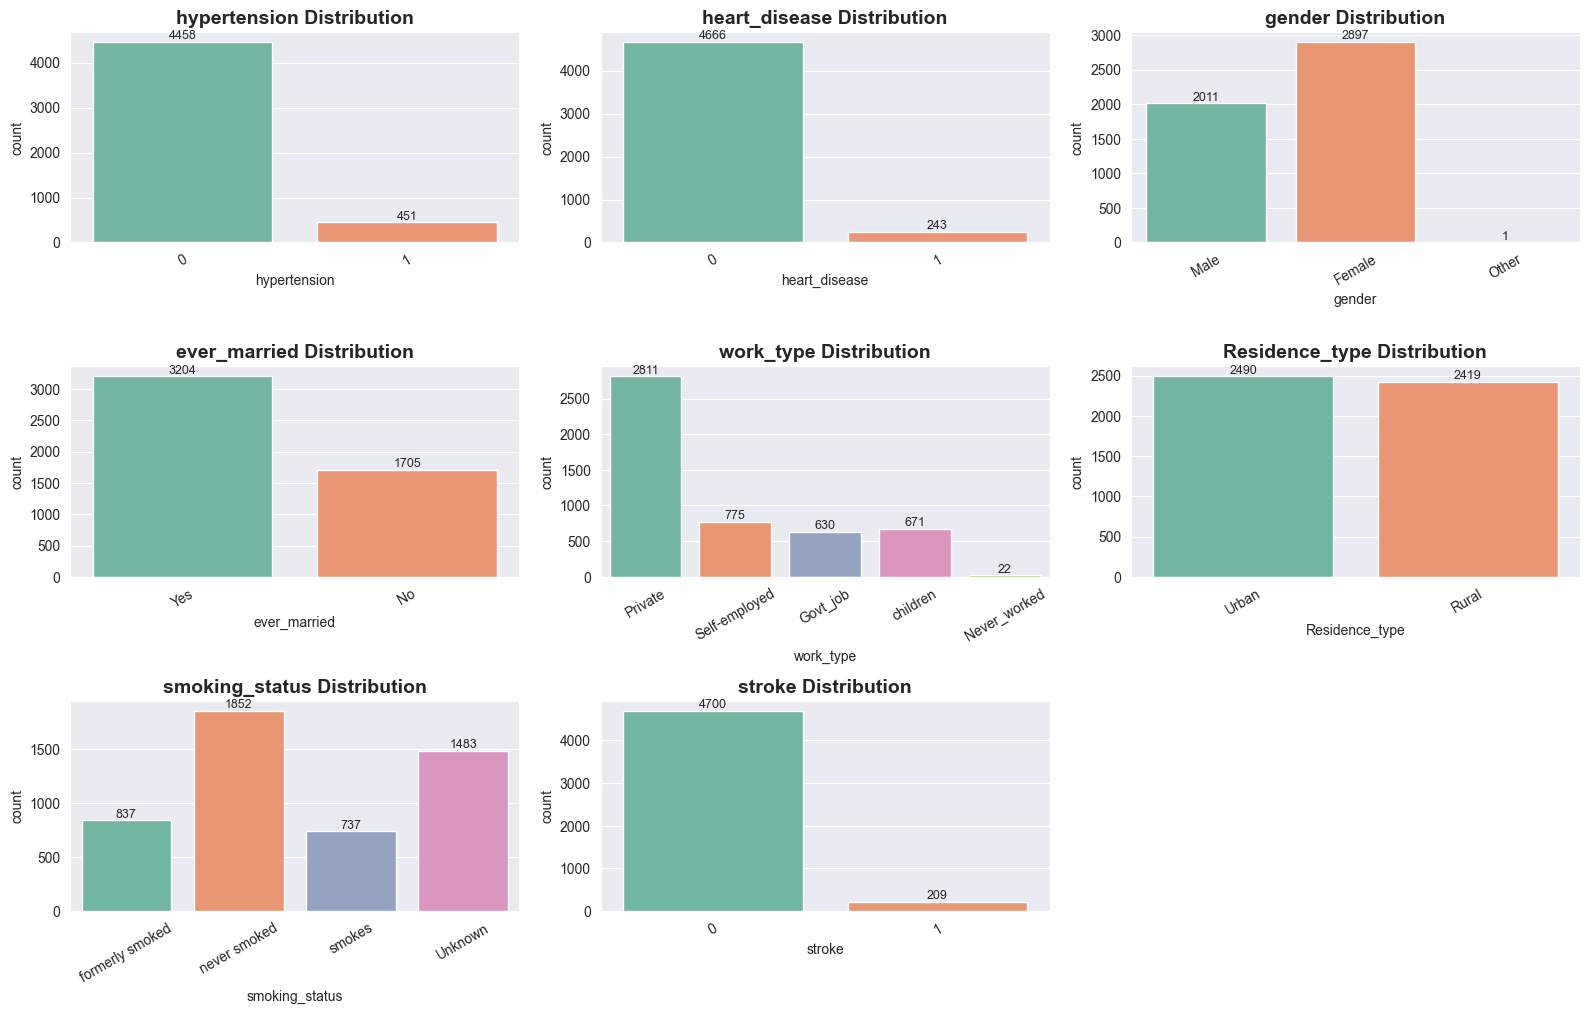

In [21]:
cols_for_count = ['hypertension','heart_disease','gender','ever_married','work_type','Residence_type','smoking_status','stroke']

sns.set_style('darkgrid')
fig , axes = plt.subplots(5,3,figsize=( 16,16))

axes = axes.flatten()

for i , col in enumerate(cols_for_count):
    ax = sns.countplot(
        data = df,
        x=col,
        ax=axes[i],
        palette="Set2")
    
    axes[i].set_title(f"{col} Distribution", fontsize=14, weight="bold")
    axes[i].tick_params(axis='x', rotation=30)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9)

if len(cols_for_count) < len(axes):
    for j in range(len(cols_for_count), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

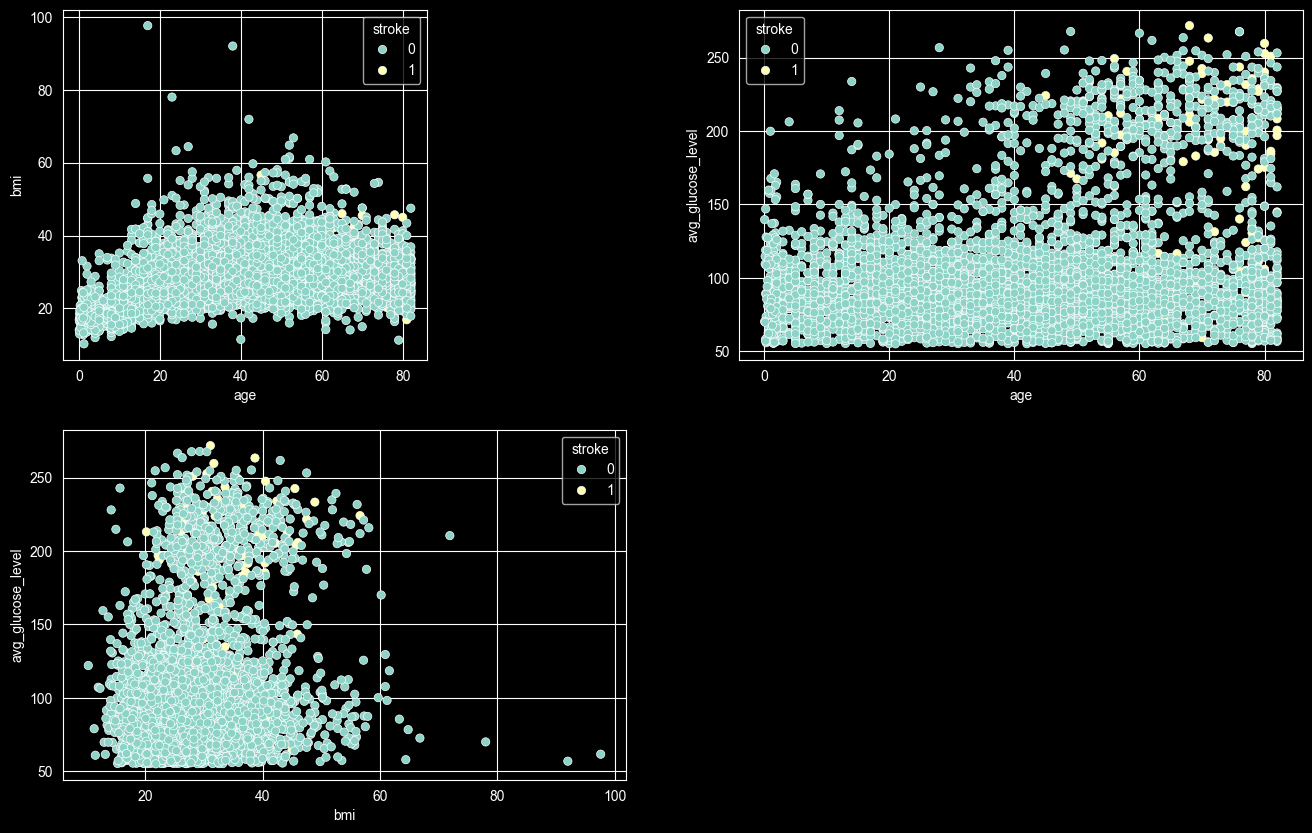

In [27]:
plt.style.use("dark_background")

plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sns.scatterplot(
    data=df,
    x = 'age',
    y = 'bmi',
    hue='stroke'
)
plt.subplot(2,2,2)
sns.scatterplot(
    data=df,
    x='age',
    y='avg_glucose_level',
    hue='stroke'
)
plt.subplot(2,2,3)
sns.scatterplot(
    data=df,
    x='bmi',
    y='avg_glucose_level',
    hue='stroke'
)
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\3954243221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\3954243221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\3954243221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8688\3954243221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` var

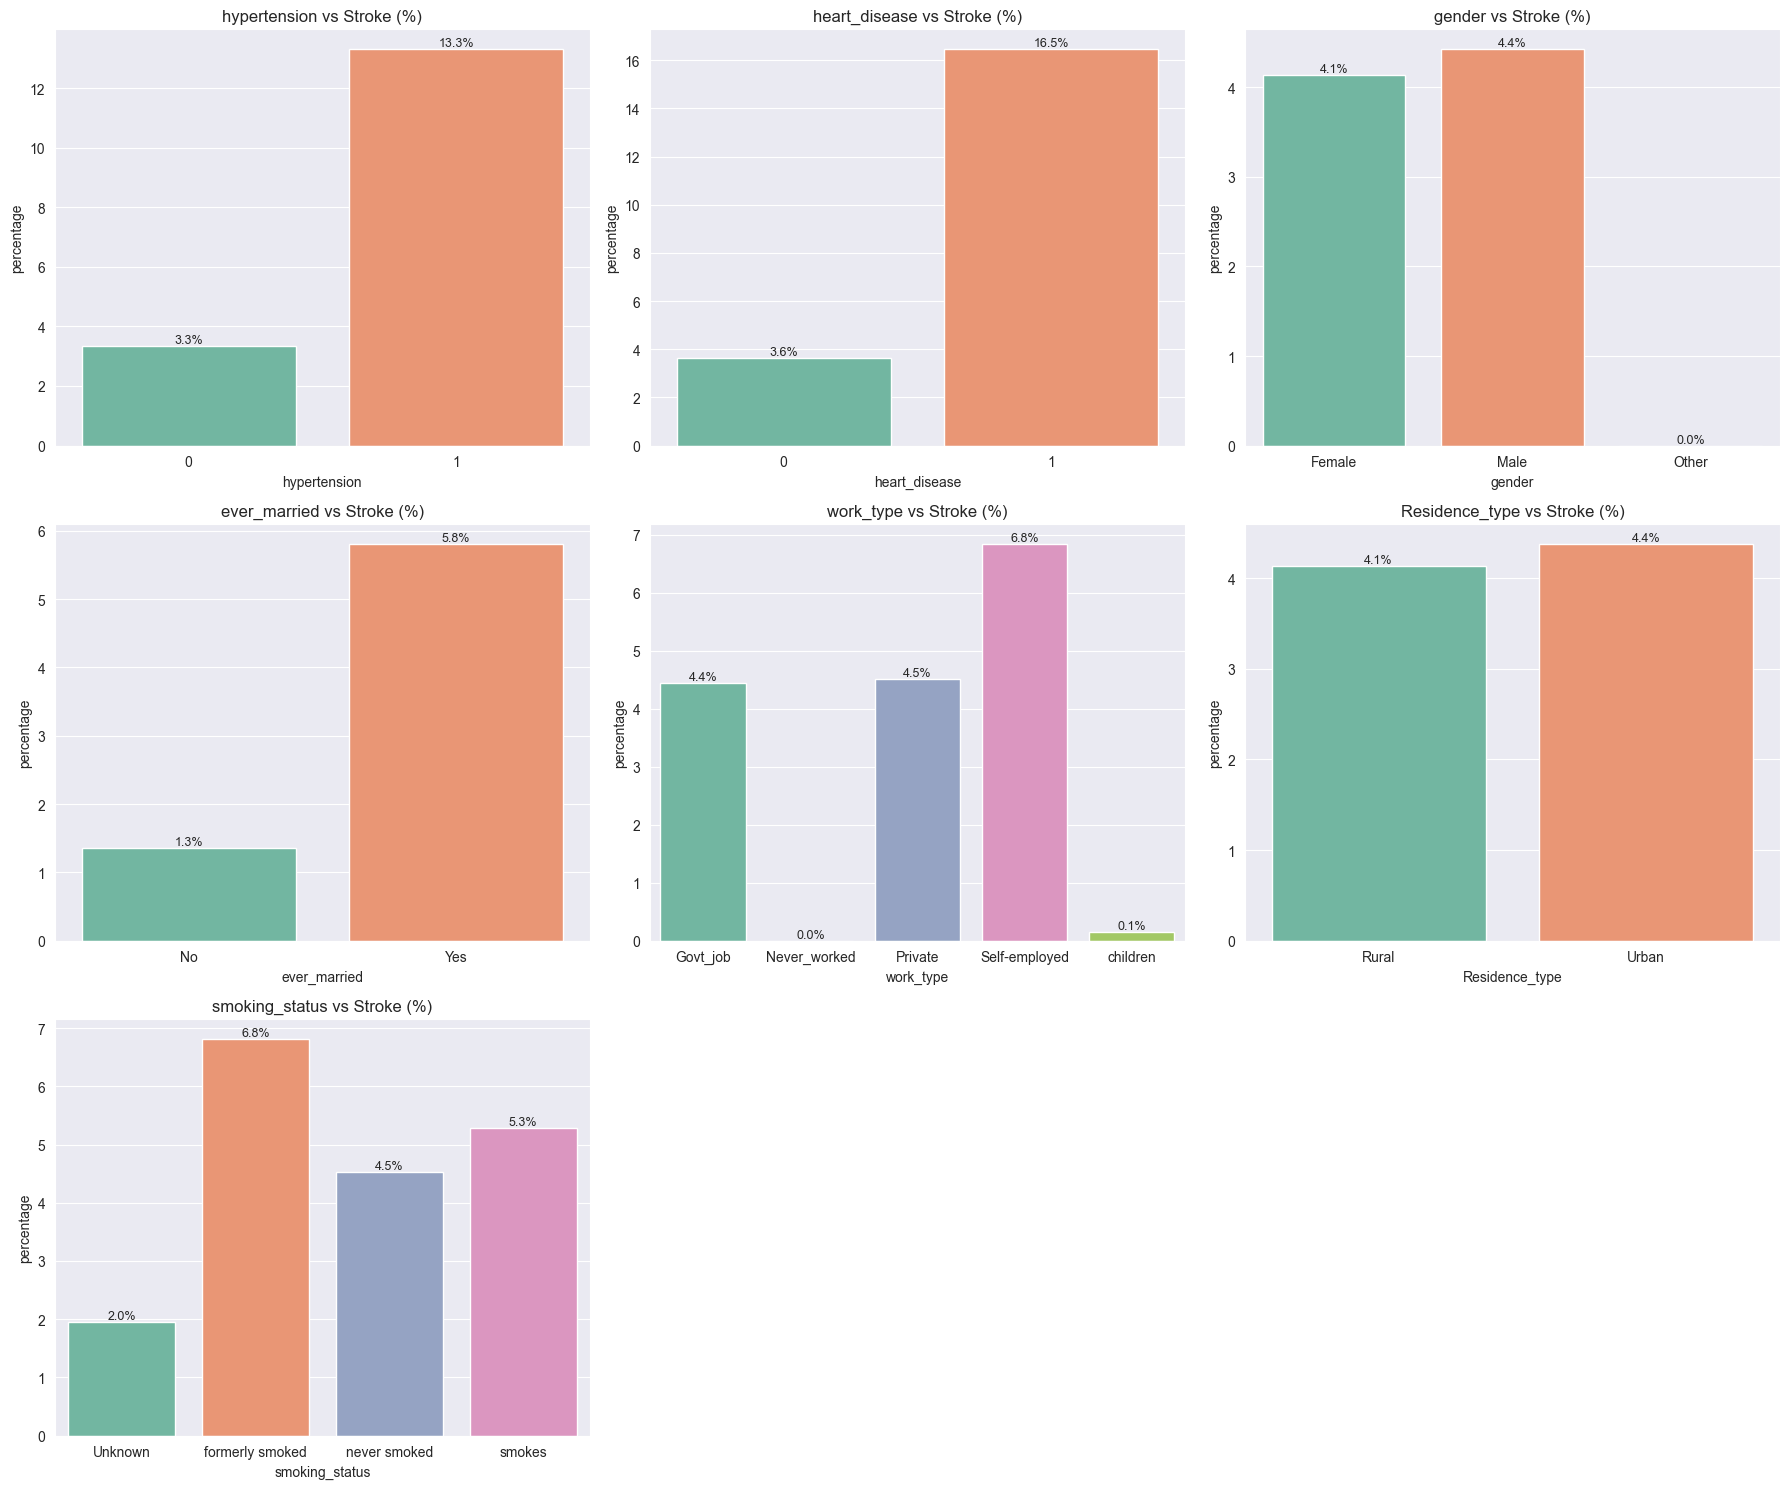

In [28]:
sns.set_style("darkgrid")

cols = [
    'hypertension',
    'heart_disease',
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    
    ratio_df = (
        df.groupby(col)['stroke']
        .mean()
        .reset_index()
    )
    ratio_df['percentage'] = ratio_df['stroke'] * 100

    ax = sns.barplot(
        data=ratio_df,
        x=col,
        y='percentage',
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Stroke (%)")

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9
        )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Label Encoding (Ordinal Encoder)

In [33]:
encoder = OrdinalEncoder()
encoding_colums = ['gender', 'ever_married','work_type','Residence_type', 'smoking_status']
df[encoding_colums] = encoder.fit_transform(df[encoding_colums])

### Decision Tree classification

In [34]:
# Prepare data for modeling
X = df.drop('stroke', axis=1)
y = df['stroke']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset prepared for modeling:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset prepared for modeling:
X_train shape: (3927, 11)
X_test shape: (982, 11)
y_train shape: (3927,)
y_test shape: (982,)


Model Accuracy Comparison
        Model  Accuracy
Decision Tree  0.919552
Random Forest  0.946029
          SVM  0.946029


Best Model: Random Forest with accuracy 0.9460


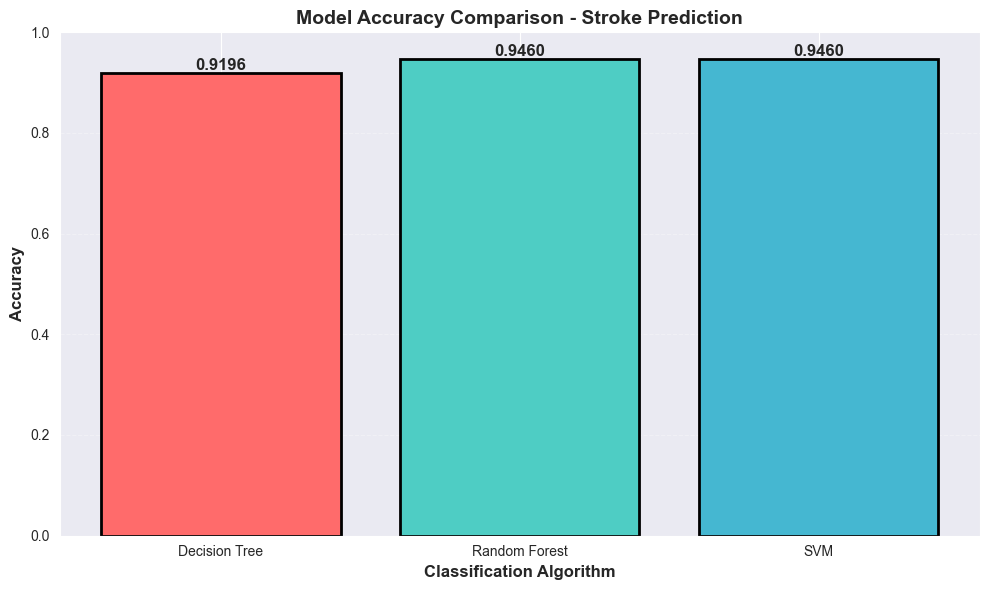

In [38]:
# Comparison of Accuracies
models = ['Decision Tree', 'Random Forest', 'SVM']
accuracies = [dt_accuracy, rf_accuracy, svm_accuracy]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print("=" * 50)
print("Model Accuracy Comparison")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("\n")
print(f"Best Model: {models[accuracies.index(max(accuracies))]} with accuracy {max(accuracies):.4f}")

# Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Algorithm', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Comparison - Stroke Prediction', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Model Accuracy Comparison

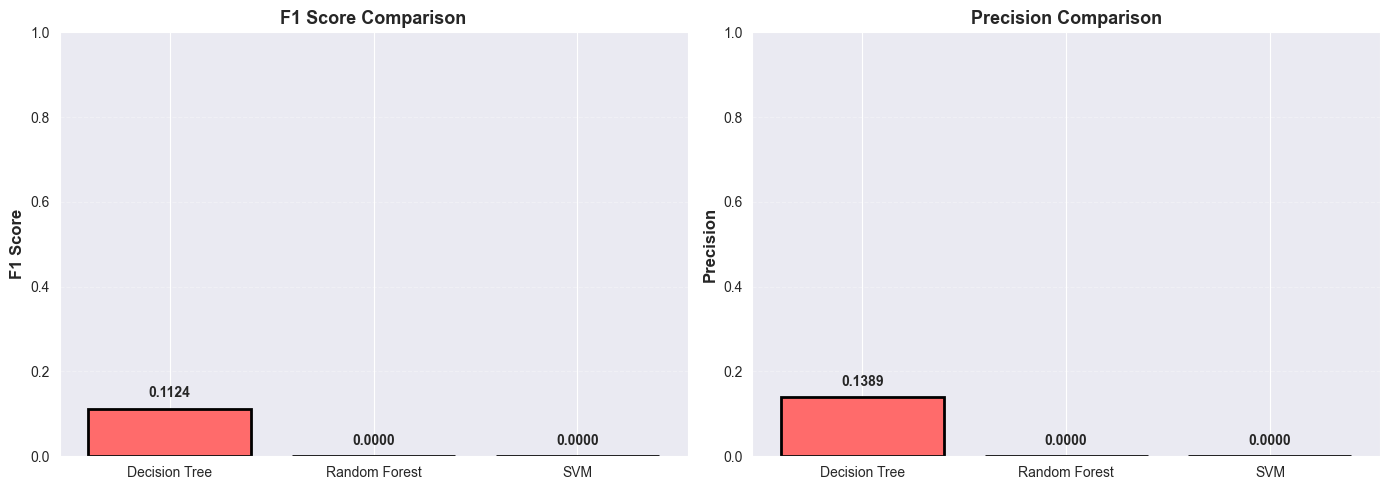

In [43]:
# Visualize F1 Score and Precision Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = ['Decision Tree', 'Random Forest', 'SVM']
f1_scores = [dt_f1, rf_f1, svm_f1]
precisions = [dt_precision, rf_precision, svm_precision]

# F1 Score comparison
axes[0].bar(models_list, f1_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=2)
axes[0].set_ylabel('F1 Score', fontsize=12, fontweight='bold')
axes[0].set_title('F1 Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Precision comparison
axes[1].bar(models_list, precisions, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=2)
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Precision Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(precisions):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [42]:
# Detailed Evaluation for each model
print("=" * 70)
print("DECISION TREE - Detailed Evaluation")
print("=" * 70)
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"F1 Score:  {dt_f1:.4f}")
print("\n" + "=" * 70)
print("RANDOM FOREST - Detailed Evaluation")
print("=" * 70)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print("\n" + "=" * 70)
print("SVM - Detailed Evaluation")
print("=" * 70)
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")

DECISION TREE - Detailed Evaluation
Accuracy:  0.9196
Precision: 0.1389
F1 Score:  0.1124

RANDOM FOREST - Detailed Evaluation
Accuracy:  0.9460
Precision: 0.0000
F1 Score:  0.0000

SVM - Detailed Evaluation
Accuracy:  0.9460
Precision: 0.0000
F1 Score:  0.0000


In [41]:
# Calculate F1 Scores and Precision Scores for all models
# F1 Score: Harmonic mean of Precision and Recall
# Precision: True Positives / (True Positives + False Positives)

# Decision Tree
dt_f1 = f1_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)

# Random Forest
rf_f1 = f1_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, zero_division=0)

# SVM
svm_f1 = f1_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, zero_division=0)

# Create evaluation dataframe
evaluation_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [dt_accuracy, rf_accuracy, svm_accuracy],
    'F1 Score': [dt_f1, rf_f1, svm_f1],
    'Precision': [dt_precision, rf_precision, svm_precision]
})

print("=" * 70)
print("Model Evaluation Metrics")
print("=" * 70)
print(evaluation_df.to_string(index=False))
print("\n")

Model Evaluation Metrics
        Model  Accuracy  F1 Score  Precision
Decision Tree  0.919552   0.11236   0.138889
Random Forest  0.946029   0.00000   0.000000
          SVM  0.946029   0.00000   0.000000




## Model Evaluation - F1 Score and Precision

In [37]:
# Support Vector Machine (SVM) Classification
svm_model = svm.SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
svm_predictions = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("=" * 50)
print("Support Vector Machine (SVM) Classification")
print("=" * 50)
print(f"Accuracy: {svm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))

Support Vector Machine (SVM) Classification
Accuracy: 0.9460

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982


Confusion Matrix:
[[929   0]
 [ 53   0]]


d:\Ibrahim\Machine_learning_practice_projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Ibrahim\Machine_learning_practice_projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Ibrahim\Machine_learning_practice_projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

### Support Vector Machine (SVM) Classification

In [36]:
# Random Forest Classification
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("=" * 50)
print("Random Forest Classification")
print("=" * 50)
print(f"Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Classification
Accuracy: 0.9460

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       929
           1       0.00      0.00      0.00        53

    accuracy                           0.95       982
   macro avg       0.47      0.50      0.49       982
weighted avg       0.89      0.95      0.92       982


Confusion Matrix:
[[929   0]
 [ 53   0]]


d:\Ibrahim\Machine_learning_practice_projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Ibrahim\Machine_learning_practice_projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Ibrahim\Machine_learning_practice_projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

### Random Forest Classification

In [35]:
# Decision Tree Classification
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("=" * 50)
print("Decision Tree Classification")
print("=" * 50)
print(f"Accuracy: {dt_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

Decision Tree Classification
Accuracy: 0.9196

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       929
           1       0.14      0.09      0.11        53

    accuracy                           0.92       982
   macro avg       0.54      0.53      0.54       982
weighted avg       0.91      0.92      0.91       982


Confusion Matrix:
[[898  31]
 [ 48   5]]
